In [68]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Input
from keras.utils import to_categorical
from matplotlib import pyplot as plt
import tensorflow as tf
import random

In [69]:
mnist_data = mnist.load_data()
(x_train, y_train), (x_test, y_test) = mnist_data
(x_train.shape, y_train.shape), (x_test.shape, y_test.shape)

(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

label: 2


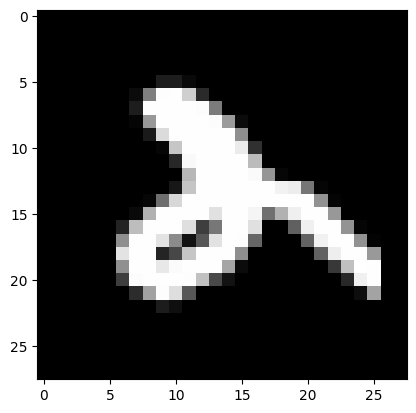

In [70]:
idx = random.randint(0, x_train.shape[0])
plt.imshow(x_train[idx], cmap='gray')
print(f'label: {y_train[idx]}')

In [71]:
y_train_labels = to_categorical(y_train, 10)
y_test_labels = to_categorical(y_test, 10)

In [72]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=8, kernel_size=3, activation='relu'),
    MaxPool2D(pool_size=2, strides=2),
    Flatten(),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', 
              metrics=[
                  'accuracy',
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall'),
                    tf.keras.metrics.AUC(name='auc')
                  ])

In [73]:
model.fit(x_train, y_train_labels, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9069 - auc: 0.9638 - loss: 2.0311 - precision: 0.9075 - recall: 0.9068
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9591 - auc: 0.9937 - loss: 0.1862 - precision: 0.9607 - recall: 0.9579
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9691 - auc: 0.9971 - loss: 0.1089 - precision: 0.9713 - recall: 0.9675
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9732 - auc: 0.9980 - loss: 0.0888 - precision: 0.9755 - recall: 0.9716
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9762 - auc: 0.9984 - loss: 0.0792 - precision: 0.9783 - recall: 0.9747


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
label: 1


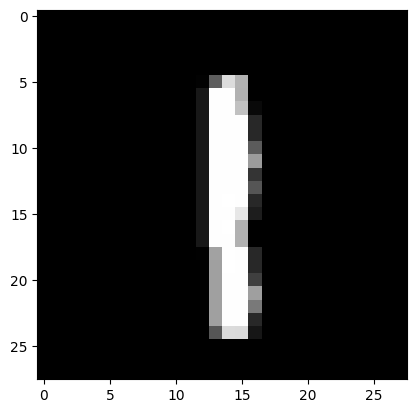

In [74]:
idx = random.randint(0, x_test.shape[0])
model.predict(x_test[idx:idx+1])
plt.imshow(x_test[idx], cmap='gray')
print(f'label: {y_test[idx]}')

In [ ]:
loss, accuracy, precision, recall, f1_score = model.evaluate(x_test, y_test_labels)
print(f'\n\nloss: {loss},\naccuracy: {accuracy},\nprecision: {precision},\nrecall: {recall},\nf1_score: {f1_score}')
model.summary()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - auc: 0.9980 - loss: 0.0916 - precision: 0.9771 - recall: 0.9733


loss: 0.09160930663347244
, accuracy: 0.9743000268936157,
precision: 0.977110743522644,
recall: 0.9732999801635742,
f1_score: 0.9979919195175171


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,832 (159.50 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,222 (106.34 KB)